In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def newton(f, df, x0, tol=1e-10, max_iter=20):

    history = []
    x = float(x0)

    for n in range(1, max_iter+1):

        fx = f(x)
        dfx = df(x)

        if dfx == 0:
            print("Derivative is zero")
            return None

        x_next = x - fx/dfx
        step = abs(x_next-x)

        history.append((n, x, x_next, step))

        if step < tol:
            return x_next, history

        x = x_next

    return x, history

In [4]:
def f(x):
    return x**3 - x - 2

def df(x):
    return 3*x**2 - 1

root, hist = newton(f, df, 1.5)

print("Root:", root)

for h in hist:
    print(h)

Root: 1.5213797068045676
(1, 1.5, 1.5217391304347827, 0.021739130434782705)
(2, 1.5217391304347827, 1.5213798059647863, 0.00035932446999642487)
(3, 1.5213798059647863, 1.5213797068045751, 9.916021115330409e-08)
(4, 1.5213797068045751, 1.5213797068045676, 7.549516567451064e-15)


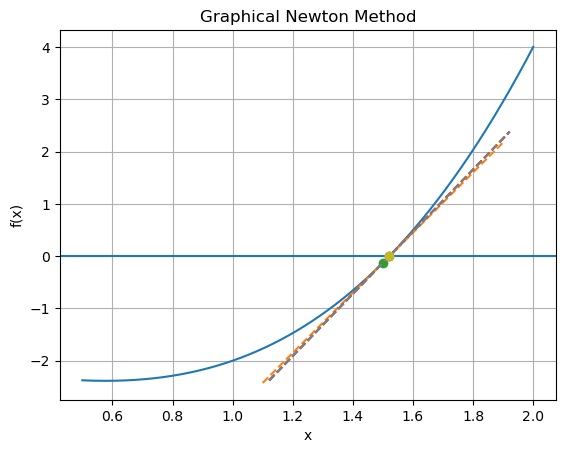

In [5]:
xs = np.linspace(0.5,2,400)
ys = [f(x) for x in xs]

plt.plot(xs,ys,label="f(x)")
plt.axhline(0)

for i in range(min(4,len(hist))):

    xn = hist[i][1]
    fxn = f(xn)
    dfxn = df(xn)

    x_tan = np.linspace(xn-0.4,xn+0.4,100)
    y_tan = fxn + dfxn*(x_tan-xn)

    plt.plot(x_tan,y_tan,'--')
    plt.plot(xn,fxn,'o')

plt.title("Graphical Newton Method")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

Comparison of Bisection, Secant, and Newton Methods

Consider the nonlinear equation
f(x)=x^3-x-2=0

The real root of this equation is approximately

𝑥≈1.5213797

This equation will be solved using three different numerical root-finding methods:

Bisection Method

Secant Method

Newton Method

In [ ]:
import math

# Example function
def f(x):
    return x+math.sin(x)-math.cos(2*x)

# Derivative for Newton method
def df(x):
    return 1+math.cos(x)+2*math.sin(2*x)


# 1) Bisection Method
def bisection(f, a, b, tol=1e-10, max_iter=100):
    if f(a) * f(b) > 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")

    history = []

    for n in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)
        error = abs(b - a) / 2

        history.append((n, a, b, c, fc, error))

        if abs(fc) < tol or error < tol:
            return c, history

        if f(a) * fc < 0:
            b = c
        else:
            a = c

    return c, history


# 2) Secant Method
def secant(f, x0, x1, tol=1e-10, max_iter=100):
    history = []

    for n in range(1, max_iter + 1):
        fx0 = f(x0)
        fx1 = f(x1)

        if fx1 - fx0 == 0:
            raise ZeroDivisionError("Division by zero in Secant method.")

        x2 = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        error = abs(x2 - x1)

        history.append((n, x0, x1, x2, f(x2), error))

        if error < tol:
            return x2, history

        x0, x1 = x1, x2

    return x2, history


# 3) Newton Method
def newton(f, df, x0, tol=1e-10, max_iter=100):
    history = []

    for n in range(1, max_iter + 1):
        fx = f(x0)
        dfx = df(x0)

        if dfx == 0:
            raise ZeroDivisionError("Derivative is zero in Newton method.")

        x1 = x0 - fx / dfx
        error = abs(x1 - x0)

        history.append((n, x0, x1, f(x1), error))

        if error < tol:
            return x1, history

        x0 = x1

    return x1, history


# Run all methods
root_bis, hist_bis = bisection(f, 1, 2)
root_sec, hist_sec = secant(f, 1, 2)
root_new, hist_new = newton(f, df, 1.5)

# Print results
print("Bisection Method")
print("Root =", root_bis)
print("Iterations =", len(hist_bis))
print()

print("Secant Method")
print("Root =", root_sec)
print("Iterations =", len(hist_sec))
print()

print("Newton Method")
print("Root =", root_new)
print("Iterations =", len(hist_new))

Bisection Method
Root = 1.5213797067990527
Iterations = 33

Secant Method
Root = 1.5213797068045676
Iterations = 8

Newton Method
Root = 1.5213797068045676
Iterations = 4


Method Comparison
1. Bisection Method
Advantages

It is very reliable.

Convergence is guaranteed if the function changes sign on the interval 
[a,b].

It does not require derivatives.

Disadvantages

The convergence rate is slow.

Requires an interval where the function values have opposite signs.

2. Secant Method
Advantages

Derivative is not required.

Usually faster than the Bisection method.

Easy to implement.

Disadvantages

Convergence is not always guaranteed.

The method can be sensitive to the initial guesses.

3. Newton Method
Advantages

Very fast convergence (quadratic convergence near the root).

Often requires very few iterations.

Disadvantages

Requires computation of the derivative 𝑓'(x).

If the initial guess is poor, the method may diverge.

If f'(x)=0, the method cannot proceed.